In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
df = pd.read_csv ("../data/GEM_APS.csv")
df.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,...,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,TIME_FORMAT,TIME_FORMAT_LABEL,COMMENT_OBS,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ARG,Argentina,GEM_APS_1,GEM Adult Population Survey: Perceived opportu...,_T,...,Units,RATIO,Ratio,602,CCYY,NaN,A,Normal value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ARM,Armenia,GEM_APS_1,GEM Adult Population Survey: Perceived opportu...,_T,...,Units,RATIO,Ratio,602,CCYY,NaN,A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AUT,Austria,GEM_APS_1,GEM Adult Population Survey: Perceived opportu...,_T,...,Units,RATIO,Ratio,602,CCYY,NaN,A,Normal value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,BLR,Belarus,GEM_APS_1,GEM Adult Population Survey: Perceived opportu...,_T,...,Units,RATIO,Ratio,602,CCYY,NaN,A,Normal value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,BIH,Bosnia and Herzegovina,GEM_APS_1,GEM Adult Population Survey: Perceived opportu...,_T,...,Units,RATIO,Ratio,602,CCYY,NaN,A,Normal value,PU,Public


In [3]:
df_clean = df.dropna(subset=('OBS_VALUE'))
df_clean['OBS_VALUE'].isna().sum()
df_clean.shape

(14569, 38)

In [4]:
opportunity_indicator = "GEM Adult Population Survey: Perceived opportunities"
df_opportunity =df_clean[df_clean["INDICATOR_LABEL"]== opportunity_indicator]
df_opportunity['INDICATOR_LABEL'].unique()


array(['GEM Adult Population Survey: Perceived opportunities'],
      dtype=object)

In [5]:
df_opportunity.shape


(1179, 38)

In [6]:
capabilities_indicator ="GEM Adult Population Survey: Perceived capabilities"
df_capabilities = df_clean[df_clean["INDICATOR_LABEL"] == capabilities_indicator]

In [7]:
df_capabilities["INDICATOR_LABEL"].unique()

array(['GEM Adult Population Survey: Perceived capabilities'],
      dtype=object)

In [8]:
df_capabilities.shape

(1179, 38)

In [9]:
df_clean['INDICATOR_LABEL'].unique()

array(['GEM Adult Population Survey: Perceived opportunities',
       'GEM Adult Population Survey: Female/Male Opportunity-Driven TEA',
       'GEM Adult Population Survey: High Job Creation Expectation',
       'GEM Adult Population Survey: Innovation',
       'GEM Adult Population Survey: Business Services Sector',
       'GEM Adult Population Survey: High Status to Successful Entrepreneurs',
       'GEM Adult Population Survey: Entrepreneurship as a Good Career Choice',
       'GEM Adult Population Survey: Perceived capabilities',
       'GEM Adult Population Survey: Fear of failure rate',
       'GEM Adult Population Survey: Entrepreneurial intentions',
       'GEM Adult Population Survey: Total early-stage Entrepreneurial Activity (TEA)',
       'GEM Adult Population Survey: Established Business Ownership',
       'GEM Adult Population Survey: Entrepreneurial Employee Activity',
       'GEM Adult Population Survey: Motivational Index',
       'GEM Adult Population Survey: Female/

In [10]:
df_opp_small =df_opportunity[['REF_AREA_LABEL','TIME_PERIOD','OBS_VALUE']]

In [11]:
df_cap_small = df_capabilities[['REF_AREA_LABEL','TIME_PERIOD','OBS_VALUE']]

In [12]:
df_opp_small = df_opp_small.rename(columns={'OBS_VALUE': 'opportunity_value'})
df_cap_small = df_cap_small.rename(columns={'OBS_VALUE': 'capability_value'})


In [13]:
df_opp_small.head()

,REF_AREA_LABEL,TIME_PERIOD,opportunity_value
0,Argentina,2024,57.00
1,Armenia,2024,51.39
2,Austria,2024,45.96
3,Belarus,2024,46.95
4,Bosnia and Herzegovina,2024,55.09


In [14]:
df_cap_small.head()

,REF_AREA_LABEL,TIME_PERIOD,capability_value
8253,Argentina,2024,74.80
8254,Armenia,2024,59.63
8255,Austria,2024,55.38
8256,Belarus,2024,52.11
8257,Bosnia and Herzegovina,2024,73.34


In [15]:
df_merged = pd.merge(
    df_opp_small,
    df_cap_small,
    on=['REF_AREA_LABEL','TIME_PERIOD'],
    how = 'inner'
)

In [16]:
df_merged.head()

,REF_AREA_LABEL,TIME_PERIOD,opportunity_value,capability_value
0,Argentina,2024,57.00,74.80
1,Armenia,2024,51.39,59.63
2,Austria,2024,45.96,55.38
3,Belarus,2024,46.95,52.11
4,Bosnia and Herzegovina,2024,55.09,73.34


In [17]:
df_merged.shape

(1179, 4)

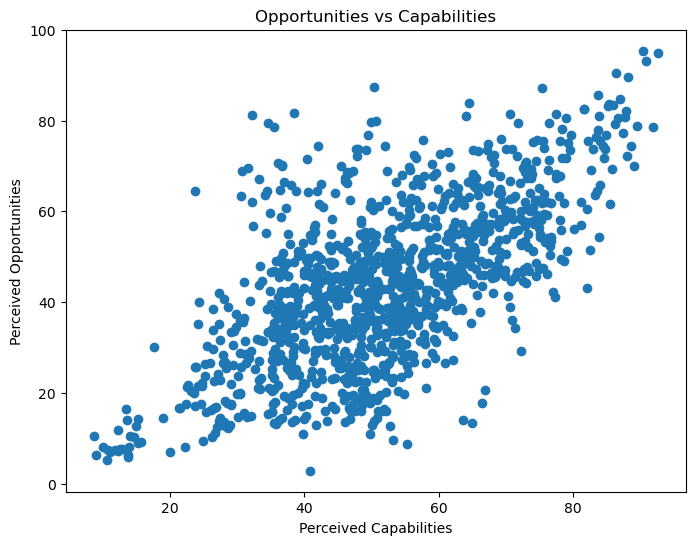

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_merged['capability_value'],
    df_merged['opportunity_value']
)

plt.xlabel("Perceived Capabilities")
plt.ylabel("Perceived Opportunities")
plt.title("Opportunities vs Capabilities")

plt.show()


In [19]:
correlation = df_merged['capability_value'].corr(df_merged['opportunity_value'])
correlation


np.float64(0.643797234598289)

In [21]:
df_merged['gap'] = df_merged['opportunity_value'] - df_merged['capability_value']

In [24]:
df_merged[[ 'TIME_PERIOD', 'opportunity_value', 'capability_value', 'gap']].head()

,TIME_PERIOD,opportunity_value,capability_value,gap
0,2024,57.00,74.80,-17.80
1,2024,51.39,59.63,-8.24
2,2024,45.96,55.38,-9.42
3,2024,46.95,52.11,-5.16
4,2024,55.09,73.34,-18.25


In [23]:
df_merged.columns


Index(['REF_AREA_LABEL', 'TIME_PERIOD', 'opportunity_value',
       'capability_value', 'gap'],
      dtype='object')